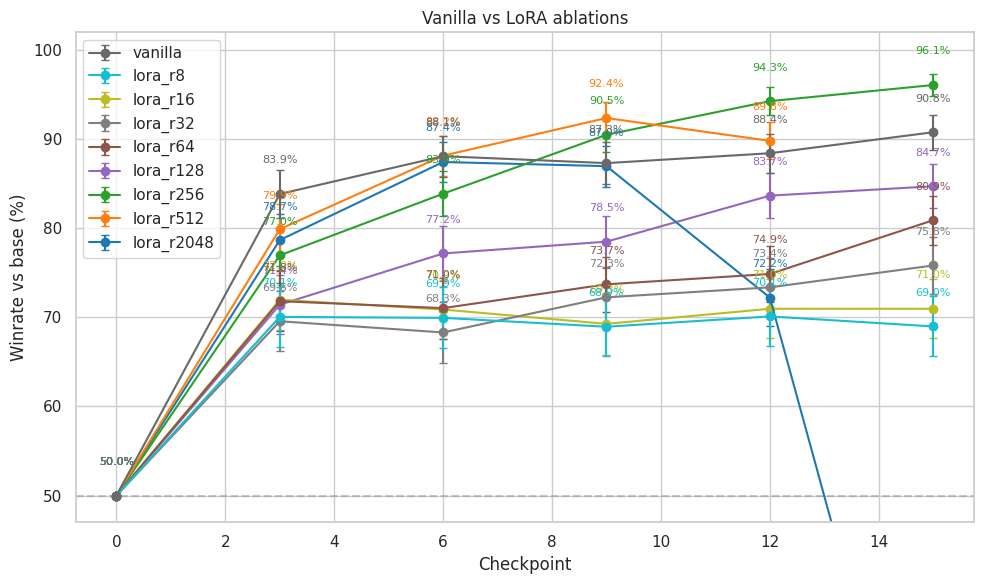

In [39]:
import json, re, seaborn as sns, matplotlib.pyplot as plt, pandas as pd, numpy as np
from pathlib import Path

rows = []
for p in Path("./eval_results").rglob("tldr_*.json"):
    d = json.load(open(p))
    model_a = d["meta"]["model_a"]
    m = re.search(r"lora[_-](\d+)", model_a)
    tag = f"lora_r{m.group(1)}" if m else "vanilla"
    ckpt = int(re.search(r"ckpt(\d+)", d["meta"]["run_name"]).group(1))
    met = d["metrics"]
    rows.append({"tag": tag, "ckpt": ckpt, "winrate": met["winrate_a_ignoring_ties"], "se": met["winrate_a_ignoring_ties_bootstrap_se"]})

df = pd.DataFrame(rows).sort_values(["tag", "ckpt"])
df = pd.concat([df] + [pd.DataFrame([{"tag": t, "ckpt": 0, "winrate": 50, "se": 0}]) for t in df.tag.unique()]).sort_values(["tag", "ckpt"])

tags = sorted(df.tag.unique(), key=lambda t: -int(re.search(r"(\d+)", t).group(1)) if "lora" in t else 1e9)
cmap = plt.colormaps["tab10"].resampled(len(tags) - 1)  # exclude vanilla from cmap
palette = {t: cmap(i) for i, t in enumerate(tags) if t != "vanilla"}
palette["vanilla"] = "dimgray"

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

tag_colors = {}
for tag, g in df.groupby("tag"):
    c = palette[tag]
    ax.errorbar(g.ckpt, g.winrate, yerr=g.se, label=tag, marker="o", capsize=3, color=c)
    tag_colors[tag] = c

ax.axhline(50, ls="--", c="gray", alpha=.4)
ax.set(xlabel="Checkpoint", ylabel="Winrate vs base (%)", title="Vanilla vs LoRA ablations")
ax.set_ylim(47, 102)

handles, labels = ax.get_legend_handles_labels()
order = sorted(range(len(labels)), key=lambda i: -1e9 if labels[i] == "vanilla" else int(re.search(r"(\d+)", labels[i]).group(1)))
ax.legend([handles[i] for i in order], [labels[i] for i in order])

for _, r in df.iterrows():
    c = tag_colors[r.tag]
    ax.annotate(f"{r.winrate:.1f}%", (r.ckpt, r.winrate), textcoords="offset points", xytext=(0, 22), ha="center", fontsize=8, color=c)
plt.tight_layout()

In [ ]:
# with Qwen/Qwen3.5-4B we have "hidden_size": 2560 so r=2048 is already a bit ridiculous